In [10]:
%load_ext autoreload
%autoreload 2

# general
from pathlib import Path
import numpy as np
from tqdm import tqdm
import pandas as pd
import os


# plotting
import seaborn as sns
import matplotlib as mp
import matplotlib.pyplot as plt
import cmcrameri.cm as cm
from helpers import plot_1_panel

mp.rcParams['font.family'] = 'serif'
mp.rcParams['font.serif'] = 'Times New Roman'
mp.rcParams['mathtext.fontset'] = 'stix'   
mp.rcParams['xtick.labelsize'] = 18
mp.rcParams['ytick.labelsize'] = 18
mp.rcParams['axes.titlesize'] = 20
mp.rcParams['axes.labelsize'] = 20
mp.rcParams['legend.title_fontsize'] = 24

# silence divide errors
import warnings
warnings.filterwarnings("ignore")

## Main

### Setup

In [11]:
DATASET_NAMES_FORMATTED = {'arxiv_math.LO': 'ArXiv Math.LO', 
                 'arxiv_math.KT': 'ArXiv Math.KT',
                'arxiv_math.GN': 'ArXiv Math.GN', 
                 'cooking-italian': 'Cooking (Italian)', 
                 'kenyan_household_H': 'Kenyan Household', 
                 'FnF_2010-08': 'Friends & Family\n(2010-08)',
                 'FnF_2010-09': 'Friends & Family\n(2010-09)',
                 'FnF_2010-10': 'Friends & Family \n(2010-10)',
                 'FnF_2010-11': 'Friends & Family\n(2010-11)',
                 'cat-edge-algebra-questions': 'Algebra questions',
                 'cat-edge-geometry-questions': 'Geometry questions',
                 'email-eu': 'Email EU',
                 'email-enron': 'Email Enron', 
                 'coauth-cs-CVPR': 'CVPR coauthorship',
                 'coauth-cs-KDD': 'KDD coauthorship',
                 'cora': 'Cora',
                 'flavourcompounds': 'Flavour Compounds',
                 'H_DAWN_0': 'DAWN',
                 'ndc-substances': 'NDC Substances',
                 'ECO-M_PL_015_plants': 'ECO-M-PL-015\nPlants',
                 'marvel': 'Marvel Universe',
                 'senate-bills': 'Senate Bills'  
                 }
DATASETS = sorted(list(DATASET_NAMES_FORMATTED.keys()))

MAXLEVELS = {'ECO-M_PL_015_plants': 30, 
 'FnF_2010-08': 10, 
 'FnF_2010-09': 12, 
 'FnF_2010-10': 14, 
 'FnF_2010-11': 20, 
 'H_DAWN_0': 15, 
 'cat-edge-DAWN': 23,
 'arxiv_math.GN': 8, 
 'arxiv_math.KT': 12, 
 'arxiv_math.LO': 15, 
 'cat-edge-algebra-questions': 30, 
 'cat-edge-geometry-questions': 30, 
 'coauth-cs-CVPR': 25, 'coauth-cs-KDD': 20, 
 'cooking-brazilian': 20, 'cooking-italian': 30, 
 'cora': 26, 
 'email-enron': 20, 
 'email-eu': 30, 'flavourcompounds': 30, 
 'kenyan_household_H': 11, 'marvel': 30, 
 'ndc-substances': 30, 'senate-bills': 30}

print(f"{len(DATASETS)} datasets")


MAIN_DATASETS = ['email-enron', 'flavourcompounds', 'arxiv_math.LO', 'FnF_2010-10'] # 'cooking-italian',  'senate-bills'


22 datasets


In [ ]:

# create 'local' data root and move data
REPO_ROOT = Path().resolve()
DATA_ROOT = REPO_ROOT / "data"
SAVE_ROOT = REPO_ROOT / "output"

print(REPO_ROOT)
print(DATA_ROOT)
print(SAVE_ROOT)

savedata = True
numreps = 100

### For those datasets available on hypergraphx-data, the following can be used. 

In [ ]:
import hypergraphx as hgx
for ds in DATASETS:
    try:
        info = hgx.get_remote_dataset_info(ds)
    except Exception as e:
        continue
    print(info)

# H = hgx.load_hypergraph_from_server(ds, store=False)
# info

{'name': 'ECO-M_PL_015_plants', 'href': 'datasets/ECO-M_PL_015_plants.html', 'tags': ['Biology', 'Undirected'], 'vertices': 131, 'edges': 477, 'categories': ['Biology', 'Undirected'], 'filename': 'ECO-M_PL_015_plants', 'directory': 'ECO-M_PL_015_plants'}
{'name': 'cat-edge-algebra-questions', 'href': 'datasets/cat-edge-algebra-questions.html', 'tags': ['Undirected', 'Edge attributed', 'Discussion forum'], 'vertices': 423, 'edges': 980, 'categories': ['Undirected', 'Edge attributed', 'Discussion forum'], 'filename': 'cat-edge-algebra-questions', 'directory': 'cat-edge-algebra-questions'}
{'name': 'cat-edge-geometry-questions', 'href': 'datasets/cat-edge-geometry-questions.html', 'tags': ['Undirected', 'Edge attributed', 'Discussion forum'], 'vertices': 580, 'edges': 888, 'categories': ['Undirected', 'Edge attributed', 'Discussion forum'], 'filename': 'cat-edge-geometry-questions', 'directory': 'cat-edge-geometry-questions'}
{'name': 'coauth-cs-CVPR', 'href': 'datasets/coauth-cs-CVPR.htm

### $\checkmark$ Main - Fig.1 - True vs. Randomised (HOCM)

In [ ]:
from hypergraphx.generation.configuration_model import configuration_model as ho_configuration_model
from helpers import calc_fingerprint_nestedness, compute_nestedness, reshape_array
from hypergraphx.readwrite import load_hypergraph


In [9]:
nreps = 100
num_steps = 20_000
savedata = True

for i, ds in enumerate(MAIN_DATASETS):
    fname_out = SAVE_ROOT / "empirical" / ds / f"MF1_HOCM{nreps}data.npz"
    if os.path.isfile(fname_out):
        print(f"{i}. Skipping {ds}")
        continue    
    print(f"{i}. {ds}")
    fname_Htrue = str(DATA_ROOT / f"{ds}.json")
    H = load_hypergraph(fname_Htrue)
    H = H.subhypergraph_by_orders(sizes=range(2, MAXLEVELS[ds]+1))
    I_true= reshape_array(calc_fingerprint_nestedness(H=H, max_level=MAXLEVELS[ds]), (MAXLEVELS[ds], MAXLEVELS[ds]), pad_value=np.nan)
    I_global_true = compute_nestedness(H.get_edges(), H.get_edges())

    I_HOCM = np.empty((nreps, MAXLEVELS[ds], MAXLEVELS[ds]))
    I_HOCM_global = []
    for j in tqdm(range(nreps)):
        H_hocm = ho_configuration_model(H, n_steps=num_steps)
        I_HOCM[j] = reshape_array(calc_fingerprint_nestedness(H=H_hocm, max_level=MAXLEVELS[ds]), (MAXLEVELS[ds], MAXLEVELS[ds]), pad_value=np.nan)
        I_HOCM_global.append(compute_nestedness(H_hocm.get_edges(), H_hocm.get_edges()))
        
    if savedata:
        if not fname_out.parent.exists(): fname_out.parent.mkdir(parents=True)
        np.savez(fname_out, I_true=I_true, I_HOCM=I_HOCM, I_global_true=I_global_true, I_HOCM_global=I_HOCM_global)


0. email-enron


100%|██████████| 100/100 [01:41<00:00,  1.01s/it]


1. flavourcompounds


100%|██████████| 100/100 [04:15<00:00,  2.55s/it]


2. arxiv_math.LO


100%|██████████| 100/100 [02:04<00:00,  1.24s/it]


3. FnF_2010-10


100%|██████████| 100/100 [02:45<00:00,  1.65s/it]


In [ ]:
def plot_Fig1_MAIN(DATASETS, nrows=5, savedata=True, nreps=100):

        startpos = 0
        ncols = len(DATASETS) // nrows

        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3.5*ncols, 4*nrows), tight_layout=True, dpi=150)


        for i, (ds, ax) in tqdm(enumerate(zip(DATASETS, axes.flatten())), total=len(DATASETS)):
                
                # Load data
                fname_hocm = SAVE_ROOT / "empirical" / ds / f"MF1_HOCM{nreps}data.npz"
                HOCM_data = np.load(fname_hocm)
                I_true = HOCM_data['I_true']
                I_HOCM = HOCM_data['I_HOCM']
                

                maxlevel_to_plot = min(MAXLEVELS[ds], I_true.shape[0]) - 3     # remove two since first entry will be for pairs
                matrix = np.nan_to_num(I_true[startpos:, startpos:].T) + np.nan_to_num(np.nanmean(I_HOCM, axis=0)[startpos:, startpos:])
                matrix = matrix[:maxlevel_to_plot, :maxlevel_to_plot]

                smallfig, smallax = plt.subplots(figsize=(4, 4), tight_layout=True, dpi=150)
                for _ax in [ax, smallax]:
                        plot_every_nth = 1 if matrix.shape[0] <= 10 else 3
                        plot_1_panel(dataArr=matrix, 
                                xticklabels=range(startpos+2, len(matrix)+2), 
                                yticklabels=range(startpos+2, len(matrix)+2), cmap=cm.devon_r, 
                                xlabel="Randomised\n(HOCM)", 
                                ylabel="Data" if i == 0 else "", 
                                vmin=np.nanmin(matrix[np.nonzero(matrix)]), vmax=np.nanmax(matrix[np.nonzero(matrix)]),
                                log_option=True,
                                step = plot_every_nth,
                                ax=_ax,
                                title=rf"{DATASET_NAMES_FORMATTED[ds]}")
                        ax.set_aspect('equal')
                        ax.plot(np.linspace(-0.5, maxlevel_to_plot-0.5, num=10), 
                                np.linspace(-0.5, maxlevel_to_plot-0.5, num=10), 
                                color='darkorange', linestyle='--', alpha=0.9, linewidth=4.0);
                
                if savedata:
                        fname_out = SAVE_ROOT / "empirical" / ds / f"mainFig1_{nreps}.png"
                        if not fname_out.parent.exists(): fname_out.parent.mkdir(parents=True)
                        smallfig.savefig(fname_out, bbox_inches='tight', dpi=300)
                        # smallax.clear();
                plt.close(smallfig)
                ax.set_title(f"{chr(i+97)}. {DATASET_NAMES_FORMATTED[ds]}")

        return fig, axes

100%|██████████| 4/4 [00:02<00:00,  1.49it/s]


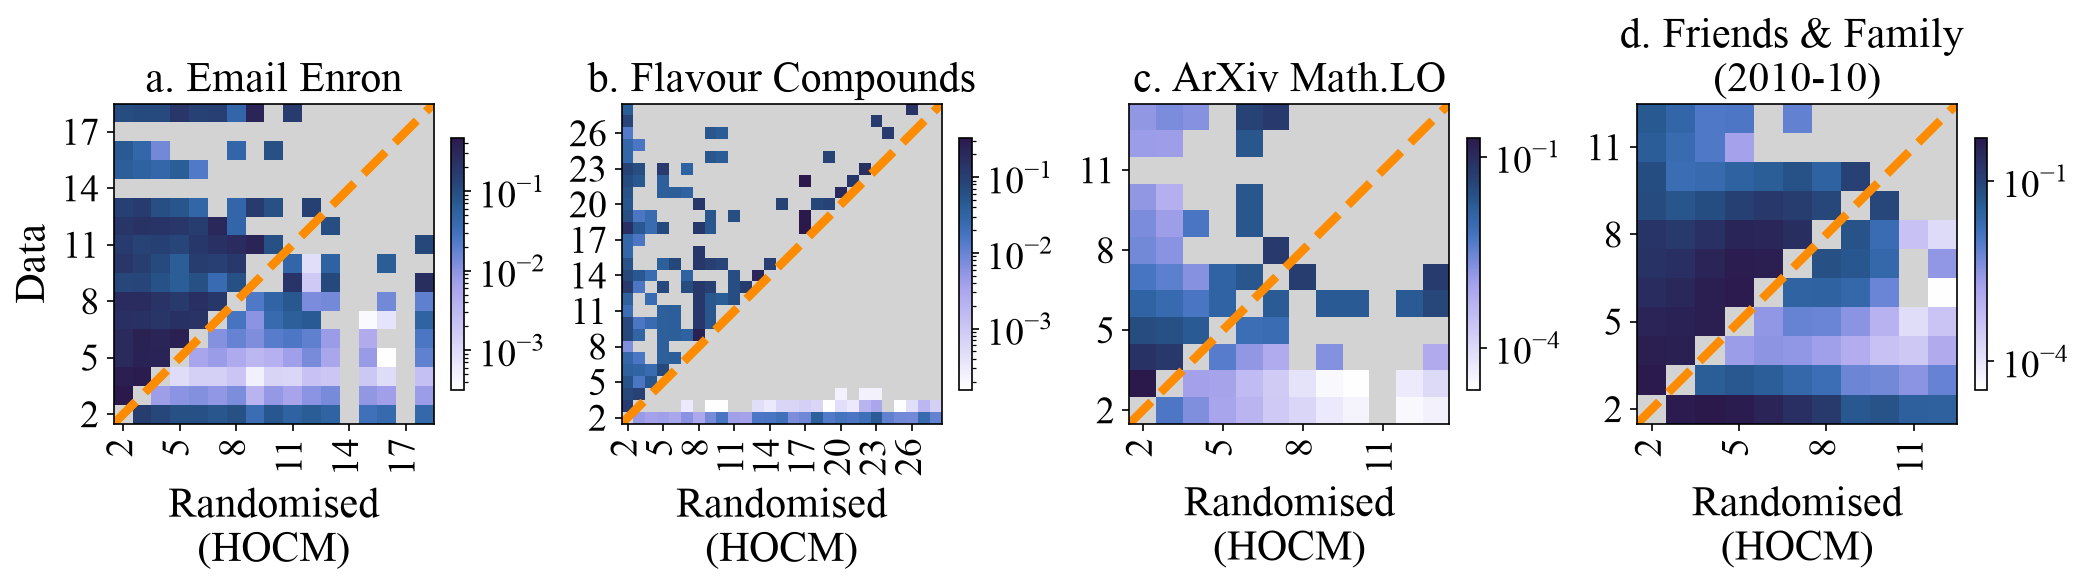

In [16]:
savedata = True

fig, axes = plot_Fig1_MAIN(DATASETS=MAIN_DATASETS, nrows=1, savedata=savedata, nreps=100)

if savedata:
    fname_out = SAVE_ROOT / "figures" / "Main_Figure1.png"
    if not fname_out.parent.exists(): fname_out.parent.mkdir(parents=True)
    fig.savefig(fname_out, bbox_inches='tight', dpi=300)

### $\checkmark$ Main - Fig.2 (schematic of model) - N/A

<img src="output/figures/Main_fig2.png" alt="drawing" width="500"/>


### $\checkmark$ Main - Fig.3 - (synthetic/numeric results)

In [17]:
import ast

mp.rcParams['font.family'] = 'serif'
mp.rcParams['font.serif'] = 'Times New Roman'
mp.rcParams['mathtext.fontset'] = 'stix'   
# default xtick fontsize
mp.rcParams['xtick.labelsize'] = 14
mp.rcParams['ytick.labelsize'] = 14
mp.rcParams['axes.labelsize'] = 16
mp.rcParams['legend.fontsize'] = 14

In [18]:
def theoryScale(bi, bj):
    if bi > bj:
        temp = bj
        bj = bi
        bi = temp
    if bi <= 1 and bj <= 1:
        return max(-1, 3 - 1/bi - 2/bj, 3 - 1/bj - 2/bi)
    elif bi >=1 and bj >= 1:
        return 0
    elif bi < 0.5 and bi < bj:
        return -1
    elif 0 < bi <= 1 < bj:
        return 1 - 1/bj
    else:
        raise ValueError(f"bi and bj problem, bi={bi}, bj={bj} ")


### Numerical Integrations

See the Wolfram file [scaling-of-nestedness-figure-3.nb](scaling-of-nestedness-figure-3.nb) for the $\beta_s = \beta_b$ case.

#### Part A

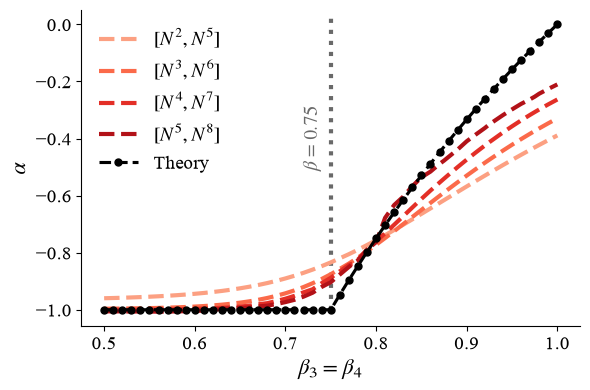

In [ ]:
# Load from Wolfram numeric integrations file
fname = DATA_ROOT / "data-fig3-from-wolfram-numeric-integrations.csv"
with open(fname, "r") as f:
    lines = f.readlines()


fig, ax = plt.subplots(1, 1, figsize=(6, 4))
labels = 	[rf"$[N^2, N^5]$", rf"$[N^3, N^6]$", rf"$[N^4, N^7]$", rf"$[N^5, N^8]$", "Theory"]
cmap = plt.get_cmap("Reds", len(labels)+2)

lw = 3

col = 'dimgrey'
ax.axvline(x=0.75, color=col, linestyle='dotted', linewidth=lw, ymin=0.05, ymax=0.99)
ax.annotate(r'$\beta=0.75$', xy=(0.73, -0.4),
            horizontalalignment='center', verticalalignment='center', rotation=+90, 
            fontsize=14, 
            color=col)


for i in range(len(lines)):
    if labels[i] == "Theory":
        continue
    l = lines[i].split('","')
    l[0] = l[0][1:]
    l[-1] = l[-1].strip('"\n')

    dat = [ast.literal_eval(x.replace("{", "(").replace("}", ")")) for x in l]
    dat = [el for el in dat if el[0]==el[1]]
    dat = np.array(dat)
    dat = dat[dat[:, 0].argsort()]

    ax.plot(dat[:, 0], dat[:, 2],
               linestyle="dashed",
               linewidth=lw,
               color=cmap(i+2), 
               label=labels[i])
    
betas = np.arange(0.5, 1.01, 0.01)
theory = [theoryScale(bi, bi) for bi in betas]
col = 'k'
plt.plot(betas, theory,
            linestyle="--",
            marker='.',
            markersize=10,
            linewidth=lw*0.75,
            color=col, label=labels[-1])

ax.set_xlabel(r"$\beta_3 = \beta_4$")
ax.set_ylabel(r"$\alpha$")

plt.legend(frameon=False)

    
# remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

if savedata:
    plt.savefig(SAVE_ROOT / "figures" / "Main_fig3a.png", 
                format="png", 
                bbox_inches='tight',
                dpi=500)

#### Part B

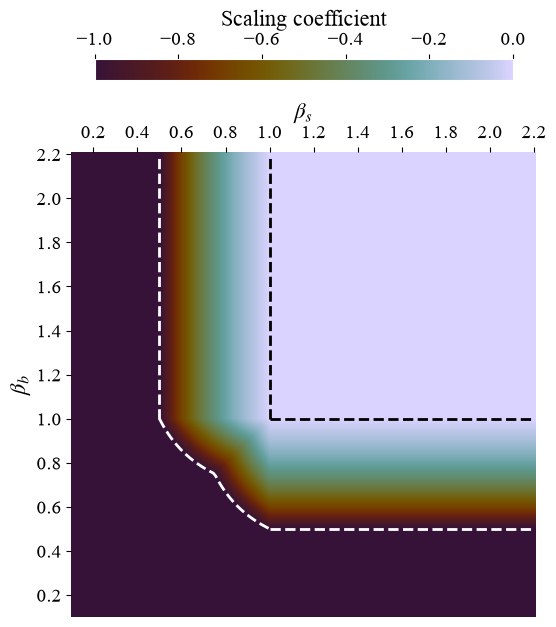

In [25]:
betas = np.linspace(0.1, 2.21, 200)
coeffs = np.zeros((len(betas), len(betas)))
cmap = cm.glasgow

for i, bi in enumerate(betas):
    for j, bj in enumerate(betas):
        if bi <= bj:
            if bi <= 1 and bj <= 1:
                coeffs[i, j] = max(-1, 3 - 1/bi - 2/bj, 3 - 1/bj - 2/bi)
            elif bi >= 1 and bj >= 1:
                coeffs[i, j] = 0
            elif bi < 0.5:
                coeffs[i, j] = -1
            elif 0 < bi <= 1 < bj:
                coeffs[i, j] = 1 - 1/bi


coeffs = coeffs + coeffs.T - np.diag(coeffs.diagonal())

fig, ax = plt.subplots(1, 1, figsize=(6, 5), dpi=100)

im = ax.imshow(coeffs.T, extent=(0.1, 2.21, 0.1, 2.21), origin='lower', cmap=cmap)
# put colorbar on the top of the plot rotated to be horizontal
cb = fig.colorbar(im, ax=ax, label= "Scaling coefficient", 
            shrink=0.9, 
            orientation='horizontal', 
            pad = -1.45
            );      # r"$\alpha$"
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')
cb.outline.set_edgecolor('white')

ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")
ax.tick_params(axis='x', labeltop=True, labelbottom=False)



ticks = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2]
labels = ['0.2', '0.4', '0.6', '0.8', '1.0', '1.2', '1.4', '1.6', '1.8', '2.0', '2.2']
ax.set_xticks(ticks)
ax.set_xticklabels(labels, rotation=0)
ax.set_yticks(ticks)
ax.set_yticklabels(labels, rotation=0)
ax.set_xlabel(r"$\beta_s$")
ax.set_ylabel(r"$\beta_b$")

for spine in ax.spines:
    ax.spines[spine].set_visible(False)

lw = 2
col = 'k'
n = 50
xvals = np.ones(n)
yvals = np.linspace(1, 2.2, n)
ax.plot(xvals, yvals, c=col, linestyle='--', linewidth=lw)
ax.plot(yvals, xvals, c=col, linestyle='--', linewidth=lw)

# n = 20
col = 'w'
xvals = np.ones(n)*0.5
yvals = np.linspace(1, 2.2, n)
ax.plot(xvals, yvals, c=col, linestyle='--', linewidth=lw)
ax.plot(yvals, xvals, c=col, linestyle='--', linewidth=lw)


def w1(x):
    if 0.5<=x<=0.75:
        return 2*x/(-1+4*x)
    elif 0.75<=x<=1:
        return x/(-2+4*x)
xvals = np.linspace(0.5, 1, n)
yvals = np.array([w1(x) for x in xvals])
xvals = np.array([el for el in xvals])
yvals = np.array([el for el in yvals])
ax.plot(xvals, yvals, c=col, linestyle='--', linewidth=lw)



if savedata:
    ftype = 'pdf'
    fname = SAVE_ROOT / "figures" / "Main_fig3b.pdf"
    plt.savefig(fname, 
                format=ftype, dpi=300, 
                bbox_inches='tight')


#### Part C

In [26]:
fname = DATA_ROOT / "overlap_l3_l4_AVERAGED.csv"
overlaps_avged = pd.read_csv(fname, index_col=0)
overlaps_avged.head()

,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,...,1.75,1.8,1.85,1.9,1.95,2.0,2.05,2.1,2.15,2.2
0.10,0.00000,0.00000,0.0,0.0,0.0,0.00000,0.0,0.00000,0.0,0.0,...,0.00000,0.00000,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0,0.00000
0.15,0.00000,0.00000,0.0,0.0,0.0,0.00000,0.0,0.00000,0.0,0.0,...,0.00002,0.00004,0.00000,0.00002,0.0,0.0,0.0,0.0,0.0,0.00002
0.20,0.00004,0.00002,0.0,0.0,0.0,0.00002,0.0,0.00000,0.0,0.0,...,0.00000,0.00000,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0,0.00000
0.25,0.00000,0.00000,0.0,0.0,0.0,0.00000,0.0,0.00002,0.0,0.0,...,0.00000,0.00000,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0,0.00000
0.30,0.00000,0.00002,0.0,0.0,0.0,0.00000,0.0,0.00000,0.0,0.0,...,0.00002,0.00000,0.00002,0.00000,0.0,0.0,0.0,0.0,0.0,0.00000


11 11


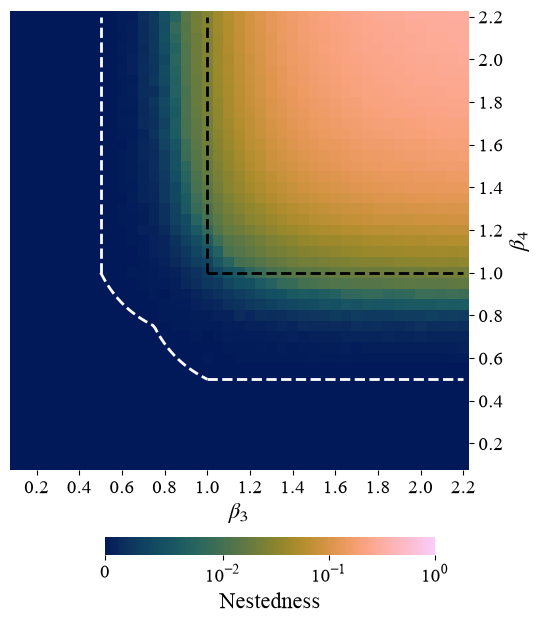

In [ ]:

from cmcrameri import cm
from matplotlib.colors import LogNorm, SymLogNorm
fig, ax = plt.subplots(1, 1, figsize=(5.5, 6), dpi=100, layout='tight')

# Manually define colorbar size and add to bottom of the plot
cbar_ax = fig.add_axes([0.2, -0.01, 0.6, 0.03])  # horizontal at bottom

cmap = cm.batlow


sns.heatmap(overlaps_avged, 
            ax=ax, 
            cmap=cmap,
            cbar=True, 
            cbar_ax=cbar_ax,
            cbar_kws={'label': 'Nestedness',
                    #    'pad': 0.25,
                        'orientation': 'horizontal',
                    },
            norm=SymLogNorm(linthresh=0.01, vmin=overlaps_avged.min().min(), vmax=1), 
            square=True)

ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
ax.tick_params(axis='y', labelright=True, labelleft=False)

cb = ax.collections[0].colorbar
cb.outline.set_edgecolor('black')
ax.set_xlabel(r"$\beta_3$")
ax.set_ylabel(r"$\beta_4$")
ax.invert_yaxis()


betas = {float(overlaps_avged.columns[i]): i+0.5 for i in range(len(overlaps_avged.columns))}
m, c = np.polyfit(list(betas.keys()), list(betas.values()), deg=1)
convert = lambda beta: m*beta + c

lw = 2

col = 'k'
n = 50
xvals = np.ones(n)*convert(1)
yvals = np.linspace(convert(1), convert(2.2), n)
ax.plot(xvals, yvals, c=col, linestyle='--', linewidth=lw)
ax.plot(yvals, xvals, c=col, linestyle='--', linewidth=lw)

# n = 20
col = 'w'
xvals = np.ones(n)*convert(0.5)
yvals = np.linspace(convert(1), convert(2.2), n)
ax.plot(xvals, yvals, c=col, linestyle='--', linewidth=lw)
ax.plot(yvals, xvals, c=col, linestyle='--', linewidth=lw)


def w1(x):
    if 0.5<=x<=0.75:
        return 2*x/(-1+4*x)
    elif 0.75<=x<=1:
        return x/(-2+4*x)
xvals = np.linspace(0.5, 1, n)
yvals = np.array([w1(x) for x in xvals])
xvals = np.array([convert(el) for el in xvals])
yvals = np.array([convert(el) for el in yvals])
ax.plot(xvals, yvals, c=col, linestyle='--', linewidth=lw)

betaticks = [round(0.2*i, 1) for i in range(1, 12)]
ticklocs = [round(convert(el), 1) for el in betaticks]
print(len(ticklocs), len(betaticks))
ax.set_xticks(ticks=ticklocs)
ax.set_xticklabels(betaticks, rotation=0)
ax.set_yticks(ticks=ticklocs)
ax.set_yticklabels(betaticks, rotation=0)
ax.set_rasterization_zorder(0)



plt.tight_layout()

if savedata:
    ftype = 'pdf'
    fname = SAVE_ROOT / "figures" / f"Main_fig3c.{ftype}"
    plt.savefig(fname, 
                format=ftype, dpi=100, 
                bbox_inches='tight')

### $\checkmark$ Main - Fig.4 - testing the HO-Geom model

In [ ]:
# GENERATING DATA

print("{1. Follow steps to download GR repo from \
      https://github.com/networkgeometry/b-mercator/tree/main \
      }\n")

print("{2. cd into geometric-randomization\ directory}\n")
"""
cd geometric-randomization
"""

print("3. make ")
"""
make clean && make 
"""

ds = 'kenyan_household_H'
maxbeta = 5
numbetas = 25
maxlevel = 10
nrealisations = 100
save_idx = 0
dot_out_file = SAVE_ROOT / "empirical" / ds / "hogeom" / "hogeom.out"
if not dot_out_file.parent.exists(): dot_out_file.parent.mkdir(parents=True)
command = f"python nestedness_whole_network.py --name {ds} --max-beta {maxbeta} --num-betas {numbetas} --max-level {maxlevel} --realisations {nrealisations} --correlation-strength 0.00 --save-idx {save_idx} --RESULTS_ROOT {SAVE_ROOT/ds/"hogeom"} -n 1  --workers 2 > {dot_out_file}"

print("{3. Run HO-Geom using: ")
print(command)
os.system(command)



{1. Follow steps to download GR repo from       https://github.com/networkgeometry/b-mercator/tree/main       }

{2. cd into geometric-randomization\ directory}

3. make 
{3. Run HO-Geom using: 


In [ ]:
from helpers import plot_diff_overall_with_crossover, bipartite_to_hypergraph, calc_fingerprint_nestedness

def plot_Fig4_MAIN(DATASETS, nrows=6, 
                   option_largest_closest='C',
                   DATA_ROOT=None,
                   betavals_desired = None                  
                   ):

        startpos = 0
        ncols = len(DATASETS) // nrows

        imwidth = 4
        fig = plt.figure(figsize=(imwidth*ncols, imwidth*nrows), 
        constrained_layout=True)
        subfigs = fig.subfigures(nrows, ncols, 
        height_ratios=[1 for _ in range(nrows)],
        # hspace=.1, wspace=.04
        )
        subfigs = subfigs.flatten()

        figctr = 0
        for i, ds in tqdm(enumerate(DATASETS), total=len(DATASETS)):
                
                fig1 = subfigs[figctr]
                figctr += 1
                #     skip not finished yet
                if ds in ['email-eu', 'marvel', 'ndc-substances', 'senate-bills']:
                        numreps=10
                else: 
                        numreps=100
                        
                if not (DATA_ROOT / "empirical" / ds / f"HOGEOM_idx0" / f"{ds}_I_panel.png").exists():
                        print(f"Skipping {ds} since not finished yet")
                        continue        


                axes1 = fig1.subplots(1, 1)
                if not isinstance(axes1, np.ndarray):
                    axes1 = [axes1]
                else:
                        print(nrows, ncols)
                        axes1 = axes1.flatten()
                ROOT_FOR_CROSSOVER = DATA_ROOT / "empirical" / ds / f"HOGEOM_idx0"
                
                # SECOND PANEL PLOT
                _, _ax, crossover_beta, DIFFS = plot_diff_overall_with_crossover(ROOT_FOR_CROSSOVER, ds);
                plt.close(_ax.figure)

                # THIRD PANEL DATA
                # Load data
                I_true = np.nan_to_num(np.loadtxt(ROOT_FOR_CROSSOVER / f"{ds}_original_nestedness_I.txt"))

                if betavals_desired is not None:
                        crossover_beta = betavals_desired[ds]
                elif option_largest_closest == 'C':
                        argmin_idx = pd.Series(DIFFS.set_index('beta').abs_diff).argmin()
                        crossover_beta = DIFFS.iloc[argmin_idx].beta
                else:
                        argmin_idx = len(DIFFS) - 1
                        crossover_beta = DIFFS.iloc[argmin_idx].beta
                

                edges = pd.read_csv(ROOT_FOR_CROSSOVER / 'realisations' / f"randomized_beta_{crossover_beta:.3f}_r_{numreps-1}_ALL.edge", sep=' ', dtype=int, header=None).values.tolist()
                H = bipartite_to_hypergraph(edges)     
                I_hogeom = calc_fingerprint_nestedness(H, max_level=MAXLEVELS[ds]+2)
                I_hogeom = np.nan_to_num(I_hogeom, nan=0.0)


                maxlevel_to_plot = min(MAXLEVELS[ds], I_true.shape[0]) - 1     # remove two since first entry will be for pairs
                matrix = np.nan_to_num(I_true.T) + np.nan_to_num(I_hogeom)
                matrix = matrix[:maxlevel_to_plot, :maxlevel_to_plot]
                
                # FIRST PANEL DATA
                fname_hocm = SAVE_ROOT / "empirical" / ds / f"MF1_HOCM100data.npz"
                HOCM_data = np.load(fname_hocm)
                I_true = HOCM_data['I_true']
                I_HOCM = HOCM_data['I_HOCM']
                                
                matrix_hocm = np.nan_to_num(I_true[startpos:, startpos:].T) + np.nan_to_num(np.nanmean(I_HOCM, axis=0)[startpos:, startpos:])
                matrix_hocm = matrix_hocm[:maxlevel_to_plot, :maxlevel_to_plot]

                _vmin = min(np.nanmin(matrix[np.nonzero(matrix)]), np.nanmin(matrix_hocm[np.nonzero(matrix_hocm)]))
                _vmax = max(np.nanmax(matrix[np.nonzero(matrix)]), np.nanmax(matrix_hocm[np.nonzero(matrix_hocm)]))
                
                plot_every_nth = 1 if matrix.shape[0] <= 10 else 3
                                        
                # THIRD PANEL PLOT
                _ax = axes1[0]
                plot_1_panel(dataArr=matrix, 
                        xticklabels=range(2, len(matrix)+2), 
                        yticklabels=range(2, len(matrix)+2), cmap=cm.devon_r, 
                        xlabel=rf"GR (HO-$\mathbb{{S}}^1$)", ylabel="Data" if i == 0 else "", 
                        vmin=_vmin, vmax=_vmax,
                        log_option=True,
                        step = plot_every_nth,
                        ax=_ax,
                        title="")
                _ax.set_aspect('equal')
                _ax.plot(np.linspace(-0.5, maxlevel_to_plot-0.5, num=10), 
                np.linspace(-0.5, maxlevel_to_plot-0.5, num=10), 
                color='darkorange', linestyle='--', alpha=0.9, linewidth=4.0);
                
                fig1.suptitle(f"{chr(97 + i)}. {DATASET_NAMES_FORMATTED[ds]}\n"+rf"$\beta={crossover_beta:.3f}$", fontsize=22);
        
        return fig

100%|██████████| 4/4 [00:01<00:00,  3.13it/s]


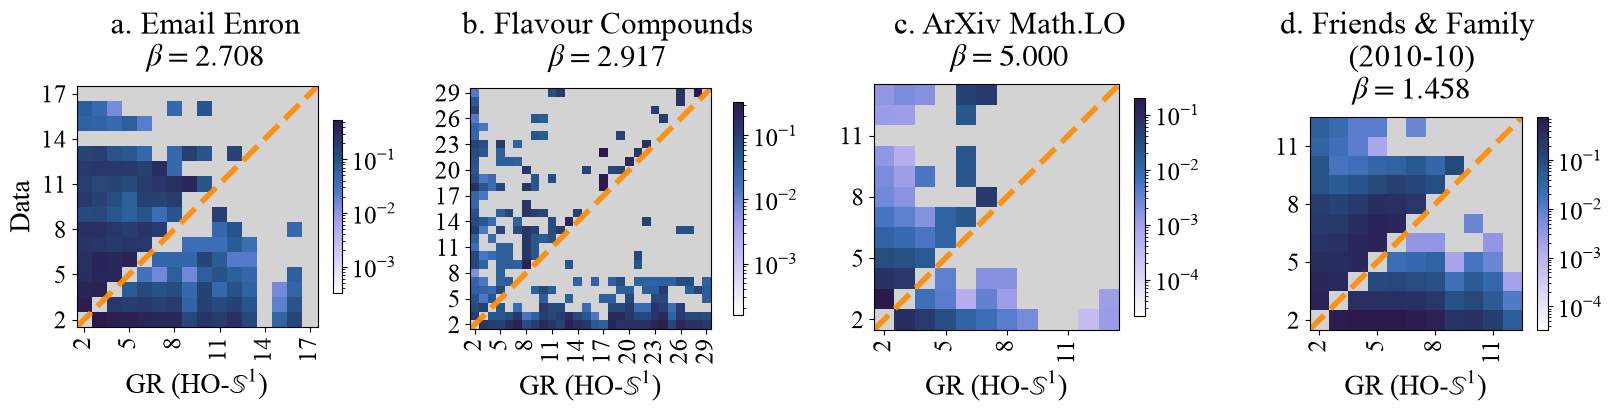

In [ ]:

fig = plot_Fig4_MAIN(DATASETS=MAIN_DATASETS, nrows=1, 
                     option_largest_closest='C',
        DATA_ROOT=DATA_ROOT, 
        betavals_desired = {'email-enron': 2.708333, 
        'flavourcompounds': 2.916667, 'arxiv_math.LO': 5.0, 'FnF_2010-10': 1.458}
               )

if savedata:
        fname_out = SAVE_ROOT / "figures" / "Main_fig4.png"
        if not fname_out.parent.exists(): fname_out.parent.mkdir(parents=True)
        fig.savefig(fname_out, dpi=300)
    
    